In [25]:
%matplotlib inline

In [2]:
dataroot = "/home/andrew/.ros/2022-09-09_overnight_train_data_combined"

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

In [4]:
os.listdir(dataroot)

['search_map.yaml',
 'brady_train_data_08:18:50',
 'mcts.yaml',
 'brady_train_data_23:34:33',
 'siva_train_data',
 'mc_testing.yaml',
 'andrew_train_data',
 'junbin_train_data',
 'brady_train_data_13:11:26']

In [5]:
from glob import glob
import re

In [6]:
particle_files = glob(dataroot + "/**/tracker_list*.csv", recursive=True)
len(particle_files)

180203

In [7]:
future_values =[]
all_n_visits = []

In [8]:
for particle_file in particle_files:
    n_visits = int(particle_file[particle_file.find("=") + 1:-4])
    drone_file = particle_file.replace("tracker_list", "state")
    drone_file = re.sub("_n_visits=\d+", "", drone_file)

    
    all_n_visits.append(n_visits)
    
    with open(drone_file, "r") as f:
        all_lines = f.readlines()
        drone_state_line = all_lines[1]
        x, y, z, heading, budget, initial_var = drone_state_line.split(",")

        result_line = all_lines[2].strip()
        future_value = result_line
        future_values.append(float(future_value) / n_visits)

In [26]:
futures = np.array(future_values)
print("mean:", futures.mean())
print("median:", np.median(futures))
print("min:", np.min(futures))
print("max:", np.max(futures))

mean: -0.07169191459880331
median: -0.0566939375
min: -0.2955915
max: -0.00143162


(array([2.7000e+01, 1.2400e+02, 2.7500e+02, 4.9000e+02, 6.9800e+02,
        1.1500e+03, 1.6030e+03, 2.2860e+03, 2.9480e+03, 3.8580e+03,
        4.7420e+03, 5.5870e+03, 6.5250e+03, 7.4070e+03, 8.2100e+03,
        8.5120e+03, 8.3630e+03, 8.6620e+03, 8.3790e+03, 7.7340e+03,
        7.6710e+03, 6.4470e+03, 1.2169e+04, 1.9740e+04, 4.6596e+04]),
 array([-0.2955915 , -0.2838251 , -0.27205871, -0.26029231, -0.24852592,
        -0.23675952, -0.22499313, -0.21322673, -0.20146034, -0.18969394,
        -0.17792755, -0.16616115, -0.15439476, -0.14262836, -0.13086197,
        -0.11909557, -0.10732918, -0.09556278, -0.08379639, -0.07202999,
        -0.0602636 , -0.0484972 , -0.03673081, -0.02496441, -0.01319802,
        -0.00143162]),
 <BarContainer object of 25 artists>)

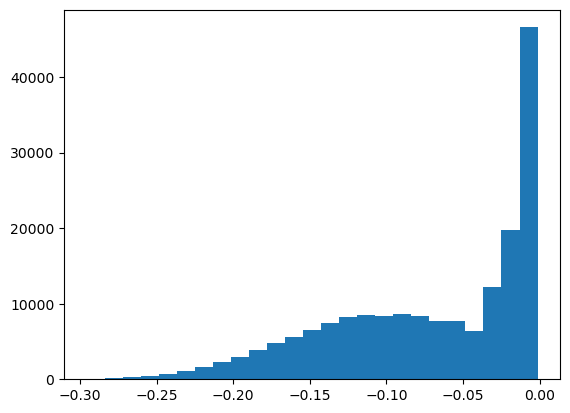

In [27]:
plt.hist(futures, bins=25)

In [28]:
n_visits = np.array(all_n_visits)
print("mean:", n_visits.mean())
print("median:", np.median(n_visits))
print("min:", np.min(n_visits))
print("max:", np.max(n_visits))

mean: 23.39770148110742
median: 3.0
min: 2
max: 31645


(array([1.79811e+05, 2.14000e+02, 5.50000e+01, 2.30000e+01, 1.80000e+01,
        1.60000e+01, 1.20000e+01, 6.00000e+00, 4.00000e+00, 9.00000e+00,
        7.00000e+00, 2.00000e+00, 8.00000e+00, 2.00000e+00, 1.00000e+00,
        7.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00, 2.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 4.00000e+00]),
 array([2.000000e+00, 1.267720e+03, 2.533440e+03, 3.799160e+03,
        5.064880e+03, 6.330600e+03, 7.596320e+03, 8.862040e+03,
        1.012776e+04, 1.139348e+04, 1.265920e+04, 1.392492e+04,
        1.519064e+04, 1.645636e+04, 1.772208e+04, 1.898780e+04,
        2.025352e+04, 2.151924e+04, 2.278496e+04, 2.405068e+04,
        2.531640e+04, 2.658212e+04, 2.784784e+04, 2.911356e+04,
        3.037928e+04, 3.164500e+04]),
 <BarContainer object of 25 artists>)

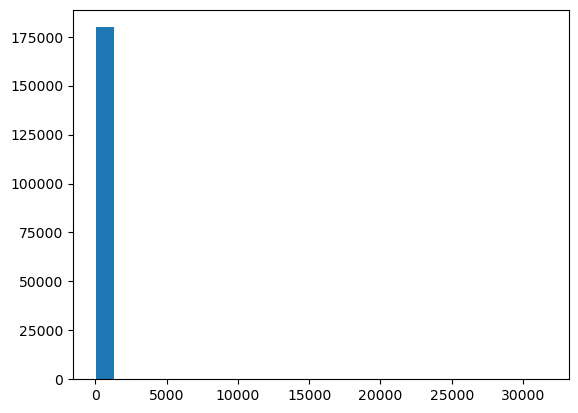

In [29]:
plt.hist(n_visits, bins=25)